In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from vizman import viz
import os
import re 

import pickle

from config import COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap, bone_white, half_black, emp_dataset_and_experiment_pairs

In [2]:
# Generate output folder
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis")
output_folder.mkdir(exist_ok=True)

# Load data 
with open(output_folder / "all_datasets_filtered.pkl", "rb") as f:
    dict_with_all_datasets = pickle.load(f)
    
# Folder now changed for saving 
output_folder = output_folder / "01_spiders_taxonomy"
output_folder.mkdir(exist_ok=True)


In [3]:
# Taxonomies 
info_mami = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_50_processed_removed_95.csv")
print(info_mami.columns)

Index(['Unnamed: 0', 'animal', 'common_name', 'name', 'species', 'genus',
       'sub_family', 'family', 'sub_order', 'order', 'super_order',
       'phylogenetic_group', 'brain_weight_g', 'brain_volume_cm3',
       'brain_data_source'],
      dtype='object')


In [18]:
from config import selected_properties

SELECTED_COLS = []
for prop, metrics in selected_properties.items():
    if metrics:
        SELECTED_COLS.append(metrics)
    else:
        print(f"Warning: No metrics selected for property '{prop}'")
        
print("Selected columns for analysis:", SELECTED_COLS)
N_SAMPLE = 100
SEED     = 42

# # ── 2. Sample & aggregate ─────────────────────────────────────────────────────
def get_stats(df, cols, n_sample, seed):
    """Return (mean_series, std_series) for the selected cols."""
    sub = df[cols].dropna()
    if len(sub) > n_sample:
        sub = sub.sample(n_sample, random_state=seed)
    return sub.mean(), sub.std(ddof=0).fillna(0)


datasets_to_look_at = ['hcp_schaefer_100_dataset_gnm', 
                       'suarez_MaMI_dataset',
                       
                        "lexis_data_young",
                        "lexis_data_aging",
                        "lexis_data_developing",
                        
                       'kaysons_generated_networks_diffusion', 
                       'kaysons_generated_networks_propagation', 
                       'kaysons_generated_networks_routing', 
                        
                       ]

Selected columns for analysis: ['global_efficiency', 'modularity', 'proportion_long_range_connections_0.3956', 'targeted_attack_robustness_rob_targeted_auc', 'algebraic_connectivity_fiedler_value', 'spectral_radius', 'computational_capacity_memory_capacity_total', 'computational_capacity_nonlinear_capacity_total', 'repertoire_sweep_weighted_by_distances_diversity_critical']


In [22]:
# Concatenate all datasets to compute global mean and std
all_data = pd.concat([dict_with_all_datasets[name][SELECTED_COLS] for name in dict_with_all_datasets if name in datasets_to_look_at])
global_mean = all_data.mean()
global_std  = all_data.std()

# Z-normalize each dataset using global statistics
dict_with_all_datasets_normalized = {
    name: (dict_with_all_datasets[name][SELECTED_COLS] - global_mean) / (global_std + 1e-8)
    for name in datasets_to_look_at # dict_with_all_datasets if name in datasets_to_look_at
}

[ 0.00908606 -0.0111891  -0.04680774  0.00874444  0.04397177 -0.02874216
  0.07104046  0.05535009  0.00724459]
[ 0.48695342 -0.24846435  0.71804052 -0.56543292 -0.25164261  0.02034476
  0.27534552  0.29282688  0.08167598]
[-0.18024314  0.11098845  0.53888575 -0.19681296 -0.59901916  0.57809544
 -1.0058658  -0.76004975  0.02163507]
[-0.14294383  0.17885682  0.45899447 -0.00641104 -0.48015828  0.2005654
 -0.78947735 -0.62221861 -0.12725135]
[-0.18169775  0.21631574  0.50401711  0.08561768 -0.4668368   0.26883819
 -0.93478396 -0.77331768 -0.20035961]
[-0.02471426  0.27141677 -0.51690568  1.34432333 -0.16255738 -1.00665238
  0.30195679  0.48240296 -0.5590715 ]
[ 1.36019717 -0.58798549 -0.93910363 -0.59243581  0.73242706  0.69598753
 -0.55680534 -0.93302313 -0.96351655]
[ 1.63665231 -1.26209601 -0.38429072 -3.79553747  1.12327378  1.0185979
  0.03965341 -0.69882134  0.35092985]


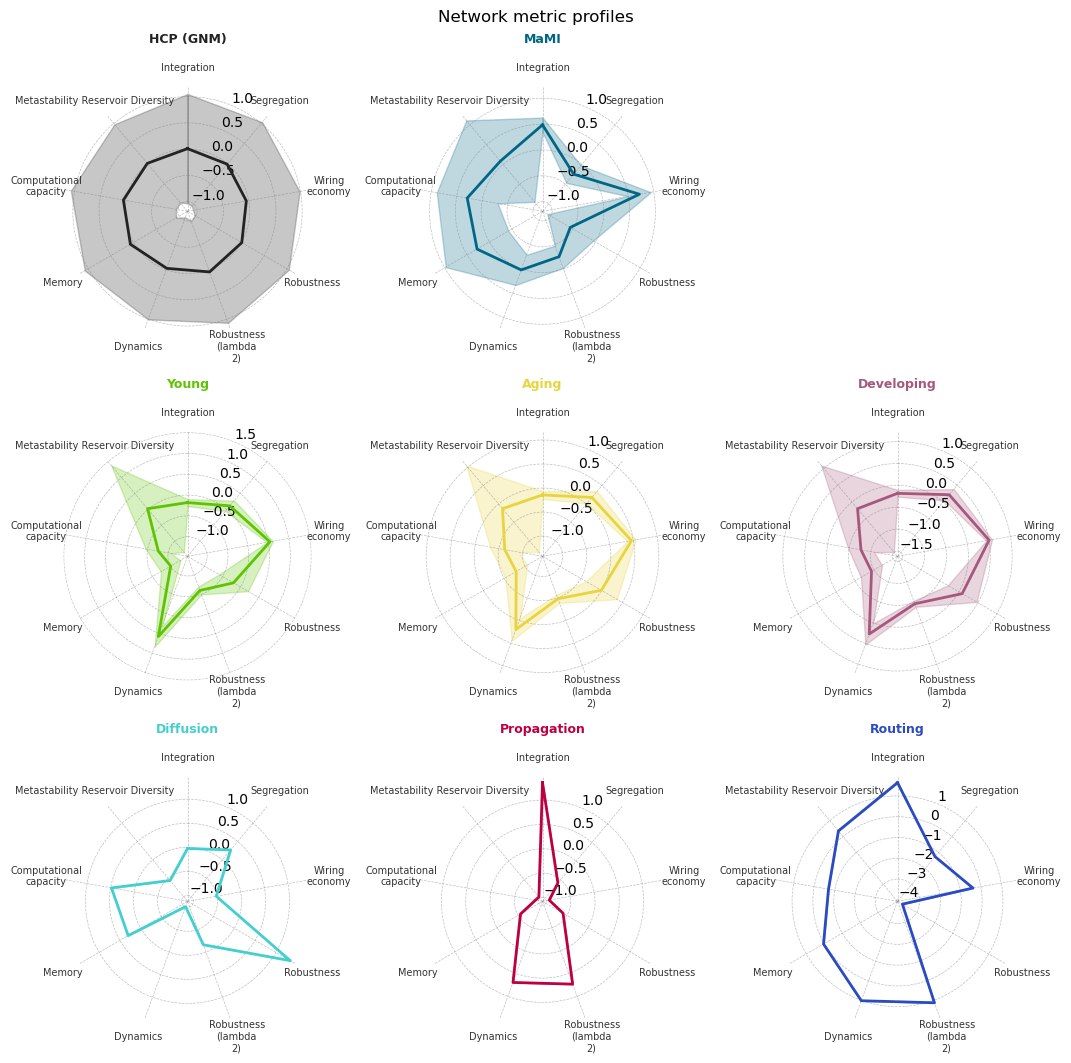

In [23]:
# ── 4. Spider-plot helper ─────────────────────────────────────────────────────
def make_spider(ax, values, errors, labels, color, title, alpha_fill=0.20):
    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]                        # close the loop

    vals = list(values) + [values[0]]
    errs = list(errors) + [errors[0]]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.plot(angles, vals, color=color, linewidth=2)
    # ax.fill(angles, vals, color=color, alpha=alpha_fill)

    # ±1 std shaded band
    # upper = np.clip(np.array(vals) + np.array(errs), 0, 1)
    # lower = np.clip(np.array(vals) - np.array(errs), 0, 1)
    upper = np.array(vals) + np.array(errs)
    lower = np.array(vals) - np.array(errs)
    ax.fill_between(angles, lower, upper, color=color, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(
        [l.replace('_', '\n') for l in labels],
        fontsize=7, color='#333333'
    )
    # ax.set_ylim(0, 1)
    # ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    # ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=6, color='grey')
    ax.set_title(title, fontsize=9, fontweight='bold', pad=14,
                 color=color, wrap=True)
    ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.spines['polar'].set_visible(False)



# ── 5. Draw ───────────────────────────────────────────────────────────────────
n_datasets = len(dict_with_all_datasets_normalized)

ncols = 3
nrows = int(np.ceil(n_datasets / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 3.6, nrows * 3.6),
    subplot_kw=dict(polar=True)
)
axes_flat = np.array(axes).flatten()

# for idx, name in enumerate(dict_with_all_datasets_normalized): 
for idx, name in enumerate(datasets_to_look_at):
    df = dict_with_all_datasets_normalized[name]
    means = df.mean().values
    stds = df.std(ddof=0).fillna(0).values # ddof value!!!
    color  = COLOR_SCHEME[name] 
    
    
    print(means)

    if idx >= 2: 
        idx = idx + 1  # skip one slot for legend
        
    make_spider(
        ax     = axes_flat[idx],
        values = means,
        errors = stds,
        labels = selected_properties.keys(),
        color  = color,
        title  = LABEL_MAP[name],
    )

# hide unused axes
for ax in axes_flat[n_datasets+1:]:
    ax.set_visible(False)

# Turn 2nd plot to empty legend panel
axes_flat[2].set_visible(False)

fig.suptitle('Network metric profiles') #  (normalised) - mean ± std',
            #  fontsize=13, fontweight='bold', y=0.9) #1.01)
plt.tight_layout() # pad=4)
# plt.savefig('spider_plots.png', dpi=150, bbox_inches='tight')
plt.show()

[ 0.00908606 -0.0111891  -0.04680774  0.00874444  0.04397177 -0.02874216
  0.07104046  0.05535009  0.00724459]
[ 0.48695342 -0.24846435  0.71804052 -0.56543292 -0.25164261  0.02034476
  0.27534552  0.29282688  0.08167598]
[-0.18024314  0.11098845  0.53888575 -0.19681296 -0.59901916  0.57809544
 -1.0058658  -0.76004975  0.02163507]
[-0.14294383  0.17885682  0.45899447 -0.00641104 -0.48015828  0.2005654
 -0.78947735 -0.62221861 -0.12725135]
[-0.18169775  0.21631574  0.50401711  0.08561768 -0.4668368   0.26883819
 -0.93478396 -0.77331768 -0.20035961]
[-0.02471426  0.27141677 -0.51690568  1.34432333 -0.16255738 -1.00665238
  0.30195679  0.48240296 -0.5590715 ]
[ 1.36019717 -0.58798549 -0.93910363 -0.59243581  0.73242706  0.69598753
 -0.55680534 -0.93302313 -0.96351655]
[ 1.63665231 -1.26209601 -0.38429072 -3.79553747  1.12327378  1.0185979
  0.03965341 -0.69882134  0.35092985]


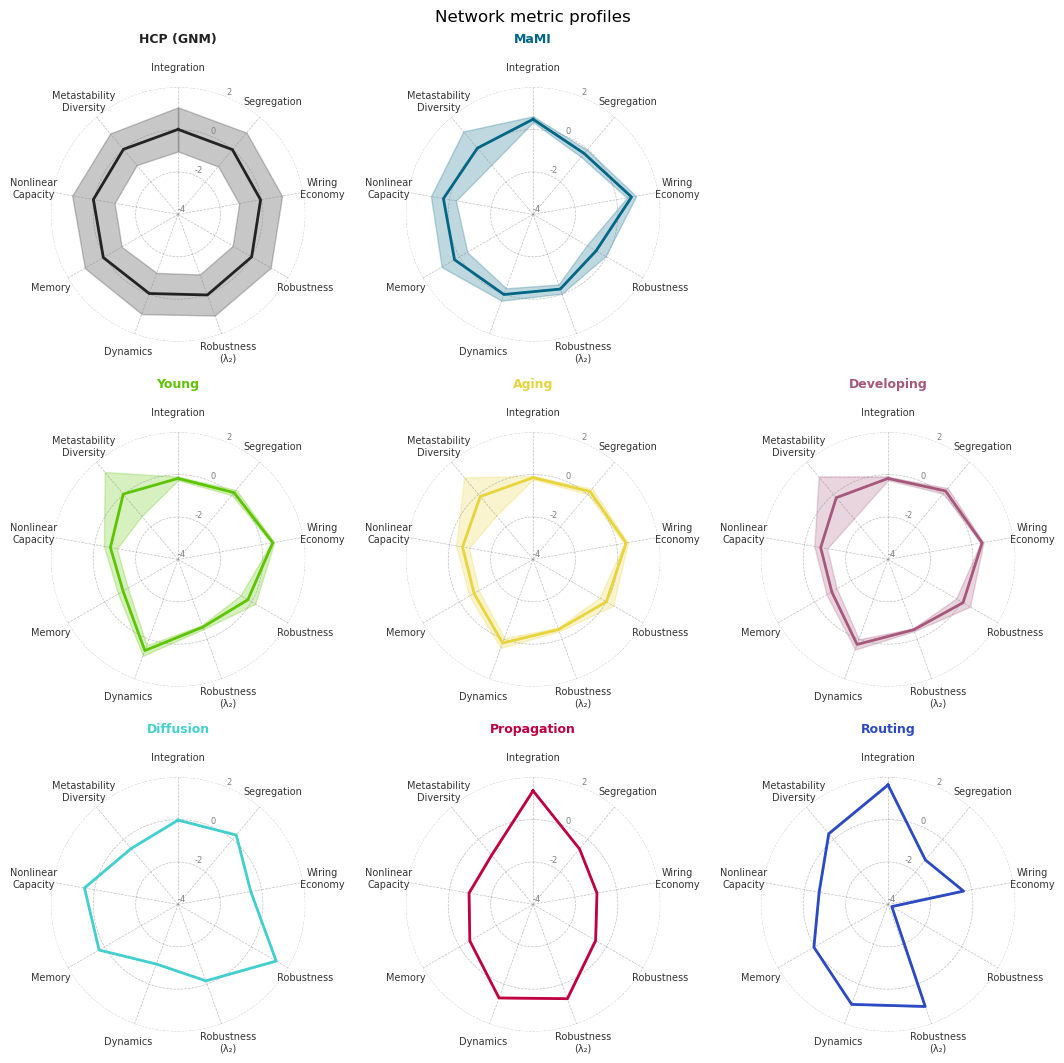

In [54]:
# ── 4. Spider-plot helper ─────────────────────────────────────────────────────
def make_spider(ax, values, errors, labels, color, title, alpha_fill=0.20):
    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]                        # close the loop

    vals = list(values) + [values[0]]
    errs = list(errors) + [errors[0]]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.plot(angles, vals, color=color, linewidth=2)
    # ax.fill(angles, vals, color=color, alpha=alpha_fill)

    # ±1 std shaded band
    # upper = np.clip(np.array(vals) + np.array(errs), 0, 1)
    # lower = np.clip(np.array(vals) - np.array(errs), 0, 1)
    upper = np.array(vals) + np.array(errs)
    lower = np.array(vals) - np.array(errs)
    ax.fill_between(angles, lower, upper, color=color, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(
        [l.replace('_', '\n') for l in labels],
        fontsize=7, color='#333333'
    )
    # ax.set_ylim(0, 1)
    ax.set_yticks([-4, -2, 0, 2]) 
    ax.set_yticklabels([-4, -2, 0, 2], fontsize=6,  # ['0.25', '0.50', '0.75', '1.00'], 
                       color='grey'
                       )
    ax.set_title(title, fontsize=9, fontweight='bold', pad=14,
                 color=color, wrap=True)
    ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.spines['polar'].set_visible(False)



# ── 5. Draw ───────────────────────────────────────────────────────────────────
n_datasets = len(dict_with_all_datasets_normalized)

ncols = 3
nrows = int(np.ceil(n_datasets / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 3.6, nrows * 3.6),
    subplot_kw=dict(polar=True)
)
axes_flat = np.array(axes).flatten()

# for idx, name in enumerate(dict_with_all_datasets_normalized): 
for idx, name in enumerate(datasets_to_look_at):
    df = dict_with_all_datasets_normalized[name]
    means = df.mean().values
    stds = df.std(ddof=0).fillna(0).values # ddof value!!!
    color  = COLOR_SCHEME[name] 
    
    
    print(means)

    if idx >= 2: 
        idx = idx + 1  # skip one slot for legend
        
    make_spider(
        ax     = axes_flat[idx],
        values = means,
        errors = stds,
        labels = selected_properties.keys(),
        color  = color,
        title  = LABEL_MAP[name],
    )

# hide unused axes
for ax in axes_flat[n_datasets+1:]:
    ax.set_visible(False)

# Turn 2nd plot to empty legend panel
axes_flat[2].set_visible(False)

fig.suptitle('Network metric profiles') #  (normalised) - mean ± std',
            #  fontsize=13, fontweight='bold', y=0.9) #1.01)
plt.tight_layout() # pad=4)
# plt.savefig('spider_plots.png', dpi=150, bbox_inches='tight')
plt.show()

hcp_schaefer_100_dataset_gnm
suarez_MaMI_dataset
lexis_data_young
lexis_data_aging
lexis_data_developing
kaysons_generated_networks_diffusion
kaysons_generated_networks_propagation
kaysons_generated_networks_routing
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/02_circular_bars/circular_bars_all_datasets.pdf


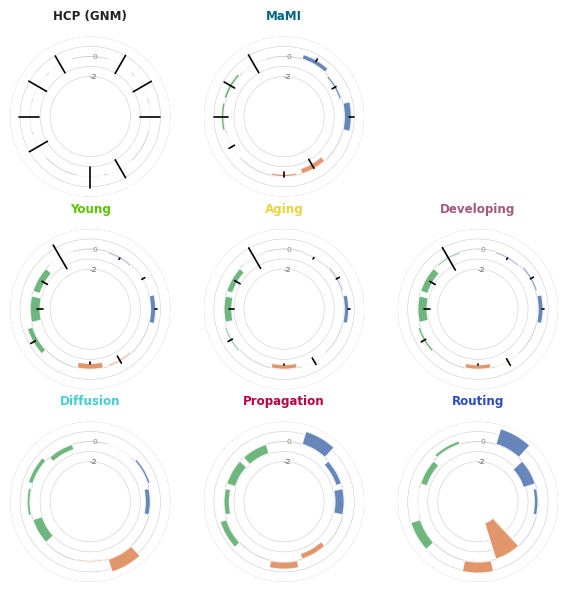

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import pickle
from config import COLORS, COLOR_SCHEME, LABEL_MAP

# ── 0. Configuration ───────────────────────────────────────────────────────────
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis")

with open(output_folder / "all_datasets_filtered.pkl", "rb") as f:
    dict_with_all_datasets = pickle.load(f)

output_folder = output_folder / "02_circular_bars"
output_folder.mkdir(exist_ok=True)

# ── 1. Properties & group structure ───────────────────────────────────────────
selected_properties = {
    "Integration":           "global_efficiency",
    "Segregation":           "modularity",
    "Wiring\nEconomy":       "proportion_long_range_connections_0.3956",
    # gap
    "Robustness":            "targeted_attack_robustness_rob_targeted_auc",
    "Robustness\n(λ₂)":     "algebraic_connectivity_fiedler_value",
    # gap
    "Dynamics":              "spectral_radius",
    "Memory":                "computational_capacity_memory_capacity_total",
    "Nonlinear\nCapacity":   "computational_capacity_nonlinear_capacity_total",
    "Metastability\nDiversity": "repertoire_sweep_weighted_by_distances_diversity_critical",
}

LABELS      = list(selected_properties.keys())
SELECTED_COLS = list(selected_properties.values())

# Group structure: (display_name, how many properties, color)
GROUPS = [
    ("Topology",                3, "#4C72B0"),
    ("Robustness",              2, "#DD8452"),
    ("Dynamics & Computation",  4, "#55A868"),
]
GROUP_SIZES  = [g[1] for g in GROUPS]
GROUP_NAMES  = [g[0] for g in GROUPS]
GROUP_COLORS = [g[2] for g in GROUPS]

# Flat color list, one per bar
BAR_COLORS = [c for (_, size, c) in GROUPS for _ in range(size)]

# # ── 2. Compute global normalization from pooled individual observations ────────
# all_pooled = pd.concat(
#     [df[SELECTED_COLS].dropna() for df in dict_with_all_datasets.values()],
#     ignore_index=True
# )
# COL_MIN   = all_pooled.min()
# COL_RANGE = (all_pooled.max() - all_pooled.min()).replace(0, 1)

# def normalise(series):
#     return (series - COL_MIN) / COL_RANGE

# # ── 3. Sample & aggregate per dataset ─────────────────────────────────────────
# N_SAMPLE = 100
# SEED     = 42

# datasets_to_plot = [
#     'hcp_schaefer_100_dataset_gnm',
#     'suarez_MaMI_dataset',
#     'kaysons_generated_networks_diffusion',
#     'kaysons_generated_networks_propagation',
#     'kaysons_generated_networks_routing',
#     "lexis_data_young",
#     "lexis_data_aging",
#     "lexis_data_developing",
# ]

# stats = {}
# for name in datasets_to_plot:
#     df  = dict_with_all_datasets[name][SELECTED_COLS].dropna()
#     sub = df.sample(min(N_SAMPLE, len(df)), random_state=SEED)
#     stats[name] = (sub.mean(), sub.std(ddof=0).fillna(0))

# ── 4. Circular bar plot helper ────────────────────────────────────────────────
PAD = 1 # 3  # empty angle slots between groups

def make_circular_bar(ax, means, stds, title, color):
    """
    One panel: grouped circular bar chart with ±1 std error bars.
    All values normalized globally to [0, 1] → plotted as [0, 100].
    """
    # mean_n = normalise(mean_raw).values * 100          # shape (N,)
    # std_n  = (std_raw / COL_RANGE).values   * 100

    N         = len(means)
    N_ANGLES  = N + PAD * len(GROUP_SIZES)
    ANGLES    = np.linspace(0, 2 * np.pi, N_ANGLES, endpoint=False)
    WIDTH     = (2 * np.pi) / N_ANGLES * 0.85

    # Which angle slots are actual bars (skip PAD slots before each group)
    offset = 0
    IDXS   = []
    GROUP_ANGLE_CENTERS = []
    for size in GROUP_SIZES:
        group_idxs = list(range(offset + PAD, offset + PAD + size))
        IDXS      += group_idxs
        GROUP_ANGLE_CENTERS.append(
            (ANGLES[group_idxs[0]] + ANGLES[group_idxs[-1]]) / 2
        )
        offset += size + PAD

    # ── Axes setup ──
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_ylim(-6, 2) # , 4) # 35, 115)
    ax.set_frame_on(False)
    ax.xaxis.grid(False)
    ax.yaxis.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])

    # ── Reference circles ──
    theta_full = np.linspace(0, 2 * np.pi, 360)
    # for ref, lw in [(25, 0.4), (50, 0.6), (75, 0.4), (100, 0.6)]:
    #     ax.plot(theta_full, [ref] * 360, color="#cccccc", lw=lw, zorder=0)
    # for ref, lw in [(-4, 0.4), (-2, 0.4), (-1, 0.4), (0, 0.6), (1, 0.4), (2, 0.4)]: # , (75, 0.4), (100, 0.6)]:
    #     ax.plot(theta_full, [ref] * 360, color="#cccccc", lw=lw, zorder=0)
    for ref, lw in [(-2, 0.4), (-1, 0.4), (0, 0.6), (1, 0.4), (2, 0.4)]:
        ax.plot(theta_full, [ref] * 360, color="#cccccc", lw=lw, zorder=0)
    # ── Bars ──
    ax.bar(
        ANGLES[IDXS], means,
        width=WIDTH, color=BAR_COLORS,
        edgecolor="white", linewidth=1,
        bottom=0, zorder=2, alpha=0.85
    )

    # ── Error bars (±1 std) ──
    for angle, val, err in zip(ANGLES[IDXS], means, stds):
        # lo = max(val - err, 0)
        # hi = min(val + err, 100)
        lo = val - err  
        hi = val + err
        ax.plot([angle, angle], [lo, hi],
                color="black", lw=1.2, zorder=3, solid_capstyle="round")

    # # ── Axis tick labels at 25 / 50 / 75 / 100 ──
    ref_angle = ANGLES[IDXS[0]] - WIDTH          # just left of first bar
    for ref in [-2, 0, -2]: # 25, 50, 75, 100]:
        ax.text(ref_angle, ref, str(ref),
                ha="center", va="center", fontsize=5.5, color="#888888")

    # ── Bar (metric) labels ──
    # for angle, val, label in zip(ANGLES[IDXS], mean_n, LABELS):
        # Flip text for the bottom half so it reads outward
        # deg = np.degrees(angle)
        # if 90 < deg < 270:
        #     rotation = deg + 90
        #     ha = "right"
        # else:
        #     rotation = deg - 90
        #     ha = "left"

        # r_label = max(val, 8) + 7      # always outside the bar
        # ax.text(angle, r_label, label,
        #         rotation=rotation, rotation_mode="anchor",
        #         ha=ha, va="center",
        #         fontsize=6.5, color="#333333")

    # # THE LEGEND RING IN THE MIDDLE 
    # offset = 0
    # for (gname, size, gcol) in GROUPS:
    #     start = offset + PAD
    #     end   = offset + PAD + size - 1
    #     x_line = np.linspace(ANGLES[start], ANGLES[end], 80)
    #     ax.plot(x_line, [-5]  * 80, color=gcol, lw=2.5)
    #     # ax.text(np.mean(x_line), -20, gname,
    #     #         color=gcol, fontsize=7, fontweight="bold",
    #     #         ha="center", va="center")
    #     offset += size + PAD

    # ── Dataset color dot + title ──
    ax.set_title(title, fontsize=8.5, 
                 fontweight="bold",
                 pad=12, 
                 color=color)


# ── 5. Draw: one panel per dataset ────────────────────────────────────────────
ncols = 3
nrows = int(np.ceil(len(datasets_to_look_at) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=viz.cm_to_inch((18,18)), # (ncols * 5.5, nrows * 5.5),
    subplot_kw=dict(projection="polar")
)
axes_flat = np.array(axes).flatten()

for idx, name in enumerate(datasets_to_look_at):
    print(name)
    if idx >= 2:
        idx += 1 # skip one panel for space where legend can go

    # mean_raw, std_raw = stats[name]
    df = dict_with_all_datasets_normalized[name]
    means = df.mean().values
    stds = df.std(ddof=0).fillna(0).values # ddof value!!!
    
    make_circular_bar(
        ax       = axes_flat[idx],
        means    = means,
        stds     = stds,
        title    = LABEL_MAP[name],
        color    = COLOR_SCHEME[name],
    )

for ax in axes_flat[len(datasets_to_look_at)+1:]:
    ax.set_visible(False)


# turn the field where the legend is going to be white 
axes_flat[2].set_facecolor("white")
axes_flat[2].set_xticks([])
axes_flat[2].set_yticks([])
axes_flat[2].set_frame_on(False)
        
        
fname = output_folder / "circular_bars_all_datasets.pdf"
plt.savefig(fname, dpi=150, bbox_inches="tight")
print(fname) 
plt.show()

['Eulipotyphla',
 'Carnivora',
 'Primates',
 'Hyracoidea',
 'Perissodactyla',
 'Lagomorpha',
 'Cetartiodactyla',
 'Xenarthra',
 'Chiroptera',
 'Marsupialia',
 'Scandentia',
 'Rodentia']

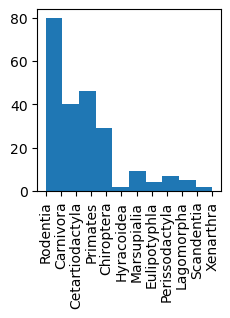

In [104]:
plt.figure(figsize=viz.cm_to_inch((6,6)))
plt.hist(info_mami["order"]) 
plt.xticks(rotation=90)
list(set(info_mami["order"]))

✓ Keeping 4 group(s): ['Carnivora', 'Cetartiodactyla', 'Primates', 'Rodentia']

Animals per 'order':
order
Rodentia           29
Cetartiodactyla    40
Primates           46
Carnivora          51

→ Minimum group size: 29 (Rodentia)


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_42053/3344084702.py:58: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=N_PER_GROUP, random_state=SEED))


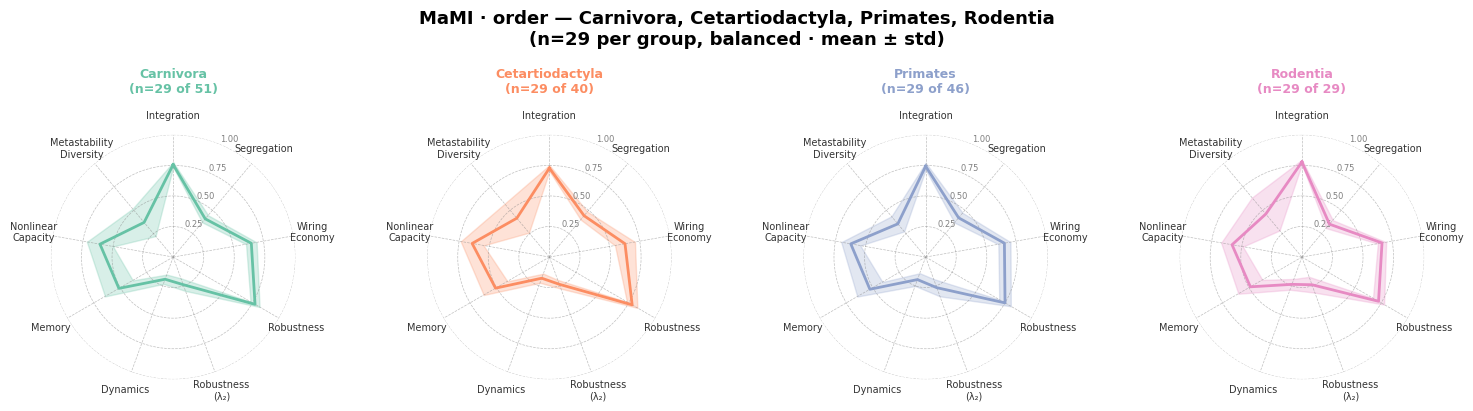

Saved → spider_mami_order.png


In [105]:
# ── 0. Configuration ──────────────────────────────────────────────────────────
what_to_look_at   = "order"
GROUPS_TO_INCLUDE = [
                    'Primates',
                    'Rodentia',
                    # 'Hyracoidea',
                    'Carnivora',
                    # 'Perissodactyla',
                    # 'Chiroptera',
                    'Cetartiodactyla',
                    # 'Eulipotyphla',
                    # 'Scandentia',
                    # 'Xenarthra',
                    # 'Lagomorpha',
                    # 'Marsupialia'
                ]

# None to include ALL groups # list(set(info_mami["order"])) #

# ── 1. Merge taxonomy with metric data ────────────────────────────────────────
mami_metrics = dict_with_all_datasets['suarez_MaMI_dataset'][SELECTED_COLS].reset_index(drop=True)
info_mami    = info_mami.reset_index(drop=True)

assert len(mami_metrics) == len(info_mami), \
    f"Row mismatch: metrics={len(mami_metrics)}, taxonomy={len(info_mami)}"

mami_full = pd.concat(
    [info_mami[['animal', 'common_name', what_to_look_at]], mami_metrics], axis=1
)

# ── 1b. Optional group filter ─────────────────────────────────────────────────
if GROUPS_TO_INCLUDE is not None:
    # Case-insensitive matching so "rodentia" == "Rodentia"
    available = mami_full[what_to_look_at].unique()
    matched   = [g for g in available
                 if g.lower() in [x.lower() for x in GROUPS_TO_INCLUDE]]
    not_found = [x for x in GROUPS_TO_INCLUDE
                 if x.lower() not in [g.lower() for g in available]]

    if not_found:
        print(f"⚠ The following groups were not found in '{what_to_look_at}' "
              f"and will be ignored: {not_found}")
    print(f"✓ Keeping {len(matched)} group(s): {sorted(matched)}")

    mami_full = mami_full[mami_full[what_to_look_at].isin(matched)].reset_index(drop=True)

# ── 2. Find minimum group size → sample that many per group ──────────────────
group_counts = mami_full.groupby(what_to_look_at).size()
print(f"\nAnimals per '{what_to_look_at}':")
print(group_counts.sort_values().to_string())
print(f"\n→ Minimum group size: {group_counts.min()} ({group_counts.idxmin()})")

N_PER_GROUP = group_counts.min()

sampled = (
    mami_full
    .groupby(what_to_look_at, group_keys=False)
    .apply(lambda g: g.sample(n=N_PER_GROUP, random_state=SEED))
    .reset_index(drop=True)
)

# ── 3. Compute per-group mean & std ───────────────────────────────────────────
group_stats = {}
for group, gdf in sampled.groupby(what_to_look_at):
    vals = gdf[SELECTED_COLS]
    group_stats[group] = (vals.mean(), vals.std(ddof=0).fillna(0))

# ── 4. Normalise across selected groups only ──────────────────────────────────
all_group_means = pd.DataFrame({k: v[0] for k, v in group_stats.items()}).T
g_min   = all_group_means.min()
g_max   = all_group_means.max()
# g_range = (g_max - g_min).replace(0, 1)

g_range = COL_RANGE
# def normalise_mami(series):
#     return (series - g_min) / COL_RANGE #  g_range

# ── 5. Plot ───────────────────────────────────────────────────────────────────
n_groups  = len(group_stats)
PALETTE   = plt.cm.Set2.colors

ncols = min(4, n_groups)
nrows = int(np.ceil(n_groups / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 3.8, nrows * 3.8),
    subplot_kw=dict(polar=True)
)
axes_flat = np.array(axes).flatten()

for idx, (group, (mean_raw, std_raw)) in enumerate(sorted(group_stats.items())):
    # mean_n = normalise_mami(mean_raw).values
    mean_n = normalise(mean_raw).values
    std_n  = (std_raw / COL_RANGE).values
    # std_n  = (std_raw / g_range).values
    color  = PALETTE[idx % len(PALETTE)]

    make_spider(
        ax     = axes_flat[idx],
        values = mean_n,
        errors = std_n,
        labels = selected_properties.keys(), # SELECTED_COLS,
        color  = color,
        title  = f"{group}\n(n={N_PER_GROUP} of {group_counts[group]})",
    )

for ax in axes_flat[n_groups:]:
    ax.set_visible(False)

group_label = "all groups" if GROUPS_TO_INCLUDE is None else ", ".join(sorted(matched))
fig.suptitle(
    f'MaMI · {what_to_look_at} — {group_label}\n'
    f'(n={N_PER_GROUP} per group, balanced · mean ± std)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()

fname = f"spider_mami_{what_to_look_at}.png"
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {fname}")

✓ Keeping 4 group(s): ['Carnivora', 'Cetartiodactyla', 'Primates', 'Rodentia']

Animals per 'order':
order
Rodentia           29
Cetartiodactyla    40
Primates           46
Carnivora          51

→ Minimum group size: 29 (Rodentia)


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_42053/2124136765.py:58: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=N_PER_GROUP, random_state=SEED))


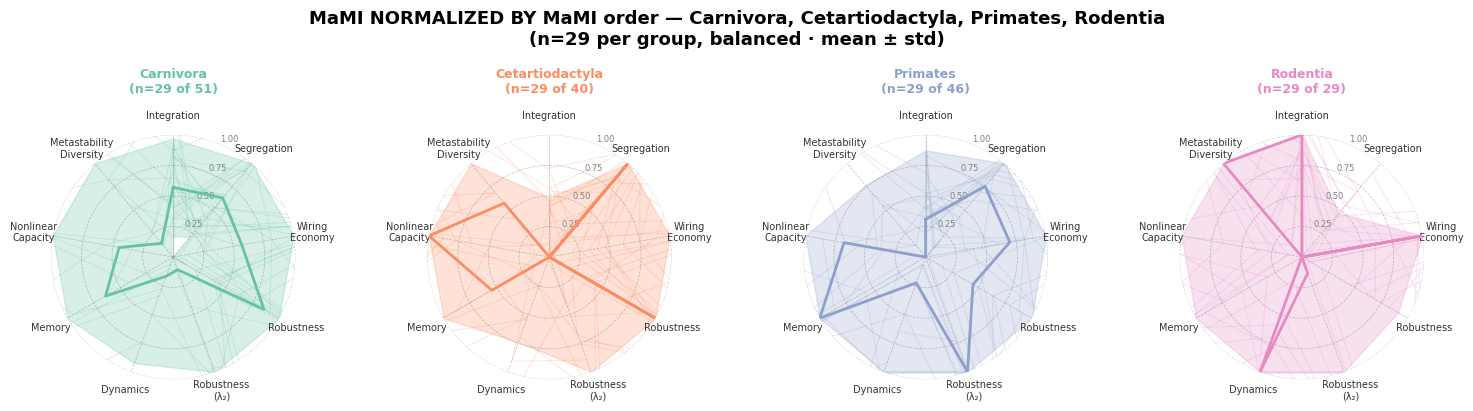

Saved → spider_mami_order.png


In [106]:
# ── 0. Configuration ──────────────────────────────────────────────────────────
what_to_look_at   = "order"
GROUPS_TO_INCLUDE = [
                    'Primates',
                    'Rodentia',
                    # 'Hyracoidea',
                    'Carnivora',
                    # 'Perissodactyla',
                    # 'Chiroptera',
                    'Cetartiodactyla',
                    # 'Eulipotyphla',
                    # 'Scandentia',
                    # 'Xenarthra',
                    # 'Lagomorpha',
                    # 'Marsupialia'
                ]

# None to include ALL groups # list(set(info_mami["order"])) #

# ── 1. Merge taxonomy with metric data ────────────────────────────────────────
mami_metrics = dict_with_all_datasets['suarez_MaMI_dataset'][SELECTED_COLS].reset_index(drop=True)
info_mami    = info_mami.reset_index(drop=True)

assert len(mami_metrics) == len(info_mami), \
    f"Row mismatch: metrics={len(mami_metrics)}, taxonomy={len(info_mami)}"

mami_full = pd.concat(
    [info_mami[['animal', 'common_name', what_to_look_at]], mami_metrics], axis=1
)

# ── 1b. Optional group filter ─────────────────────────────────────────────────
if GROUPS_TO_INCLUDE is not None:
    # Case-insensitive matching so "rodentia" == "Rodentia"
    available = mami_full[what_to_look_at].unique()
    matched   = [g for g in available
                 if g.lower() in [x.lower() for x in GROUPS_TO_INCLUDE]]
    not_found = [x for x in GROUPS_TO_INCLUDE
                 if x.lower() not in [g.lower() for g in available]]

    if not_found:
        print(f"⚠ The following groups were not found in '{what_to_look_at}' "
              f"and will be ignored: {not_found}")
    print(f"✓ Keeping {len(matched)} group(s): {sorted(matched)}")

    mami_full = mami_full[mami_full[what_to_look_at].isin(matched)].reset_index(drop=True)

# ── 2. Find minimum group size → sample that many per group ──────────────────
group_counts = mami_full.groupby(what_to_look_at).size()
print(f"\nAnimals per '{what_to_look_at}':")
print(group_counts.sort_values().to_string())
print(f"\n→ Minimum group size: {group_counts.min()} ({group_counts.idxmin()})")

N_PER_GROUP = group_counts.min()

sampled = (
    mami_full
    .groupby(what_to_look_at, group_keys=False)
    .apply(lambda g: g.sample(n=N_PER_GROUP, random_state=SEED))
    .reset_index(drop=True)
)

# ── 3. Compute per-group mean & std ───────────────────────────────────────────
group_stats = {}
for group, gdf in sampled.groupby(what_to_look_at):
    vals = gdf[SELECTED_COLS]
    group_stats[group] = (vals.mean(), vals.std(ddof=0).fillna(0))

# ── 4. Normalise across selected groups only ──────────────────────────────────
all_group_means = pd.DataFrame({k: v[0] for k, v in group_stats.items()}).T
g_min   = all_group_means.min()
g_max   = all_group_means.max()
g_range = (g_max - g_min).replace(0, 1)

# g_range = COL_RANGE
def normalise_mami(series):
    return (series - g_min) / g_range

# ── 5. Plot ───────────────────────────────────────────────────────────────────
n_groups  = len(group_stats)
PALETTE   = plt.cm.Set2.colors

ncols = min(4, n_groups)
nrows = int(np.ceil(n_groups / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 3.8, nrows * 3.8),
    subplot_kw=dict(polar=True)
)
axes_flat = np.array(axes).flatten()

for idx, (group, (mean_raw, std_raw)) in enumerate(sorted(group_stats.items())):
    # mean_n = normalise_mami(mean_raw).values
    mean_n = normalise_mami(mean_raw).values
    # std_n  = (std_raw / COL_RANGE).values
    std_n  = (std_raw / g_range).values
    color  = PALETTE[idx % len(PALETTE)]
    ax = axes_flat[idx]
    
    # ── Individual animal contours (low alpha) ────────────────────────────
    group_df = sampled[sampled[what_to_look_at] == group][SELECTED_COLS]
    n_cols   = len(SELECTED_COLS)
    angles   = np.linspace(0, 2 * np.pi, n_cols, endpoint=False).tolist()
    angles  += angles[:1]  # close the polygon

    for _, row in group_df.iterrows():
        ind_n  = normalise_mami(row).values.tolist()
        ind_n += ind_n[:1]  # close the polygon
        ax.plot(angles, ind_n, color=color, alpha=0.2, # 12, 
                linewidth=0.8)
        # ax.fill(angles, ind_n, color=color, alpha=0.03)
        

    make_spider(
        ax     = ax,
        values = mean_n,
        errors = std_n,
        labels = selected_properties.keys(), # SELECTED_COLS,
        color  = color,
        title  = f"{group}\n(n={N_PER_GROUP} of {group_counts[group]})",
    )

for ax in axes_flat[n_groups:]:
    ax.set_visible(False)

group_label = "all groups" if GROUPS_TO_INCLUDE is None else ", ".join(sorted(matched))
fig.suptitle(
    f'MaMI NORMALIZED BY MaMI {what_to_look_at} — {group_label}\n'
    f'(n={N_PER_GROUP} per group, balanced · mean ± std)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()

fname = f"spider_mami_{what_to_look_at}.png"
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {fname}")

In [107]:
# Sort by alphabet and print
print(sorted(set(info_mami["name"])))

info_mami["name_cleaned"] = info_mami["name"].str.replace(" ", "_").str.lower()


['Addax', 'Agouti', 'Armadillo', 'Artibeus Jamacien', 'Asellia', 'Asian Otter', 'Baboon', 'Bactrian Deer', 'Battongia', 'Blanford Fox', 'Blind Mole', 'Bottle Nose Dolphin', 'Brown Lemur', 'Capra Nubiana', 'Capuchin', 'Capybara', 'Caracal', 'Carollia Perspicilatta', 'Cat', 'Caucasian Squirrel', 'Chaerephon Plicata', 'Chimpanzee', 'Chinchila', 'Chital', 'Colobus', 'Common Fox', 'Common Hedge Hog', 'Common Tree Shrew', 'Cow', 'Coypu', 'Cynopterus', 'Deer', 'Dego', 'Dik Dik', 'Dog', 'Donkey', 'Eonycteris', 'Eptesicus', 'Fallow Deer', 'Fennek Fox', 'Ferret', 'Fruit Bat', 'Gerbil', 'Giraffe', 'Goat', 'Golden Spiny Mouse', 'Gorilla', 'Gray Kangaroo', 'Green Monkey', 'Hare', 'Himalian Bear', 'Hipp Armiger', 'Honey Badger', 'Horse', 'Howler Monkey', 'Hyaena', 'Hyrax', 'Ind Hog Deer', 'Jungle Cat', 'Koala', 'Lama', 'Lemur Catta', 'Leopard', 'Lycaon', 'Macaque', 'Macaque Black', 'Macaque Lion Tail', 'Macaque P T', 'Mandrill', 'Mangebi', 'Mara', 'Marmoset', 'Meerkat', 'Merion', 'Miniopterus Schrei

In [108]:
# Replace the following: 
info_mami["name_cleaned"] = info_mami["name_cleaned"].replace({
    "stripped_dolphin": "dolphin", # stripped_
    "macaque_black": "macaque", # _black",
    "macaque_lion_tail": "macaque",
    "macaque_p_t": "macaque",
    "marmoset": "marmoset",
    "mouse": "mouse",
    "rabbit": "rabbit",
    "rat": "rat"
})

In [109]:
# "Chimpanzee", "Dog", "Cat", "Dolphin", "Stripped Dolphin", "Macaque", "Macaque Black", "Macaque Lion Tail", "Macaque P T", "Marmoset", "Mouse", "Rabbit", "Rat"

In [110]:
# Count occurrences of each name
name_counts = info_mami["name_cleaned"].value_counts()
for i,n in name_counts.items():
    print(f"{i}: {n}")

macaque: 11
dog: 7
rat: 6
cat: 6
meerkat: 5
fruit_bat: 5
baboon: 5
capra_nubiana: 4
ferret: 4
nasua: 3
lycaon: 3
goat: 3
capuchin: 3
otter: 3
wolf: 3
brown_lemur: 3
giraffe: 3
fallow_deer: 3
red_kangaroo: 3
wild_rabbit: 3
common_hedge_hog: 3
orangutan: 3
oryx: 3
lama: 2
tapir: 2
gray_kangaroo: 2
howler_monkey: 2
tamarin_emperor: 2
eptesicus: 2
porcupine: 2
pkuhlii: 2
wild_rat: 2
horse: 2
bactrian_deer: 2
leopard: 2
wild_boar: 2
tamarin_cotton_top: 2
pecari: 2
chital: 2
tadarida_teniotis: 2
carollia_perspicilatta: 2
mandrill: 2
green_monkey: 2
dolphin: 2
blind_mole: 2
sand_cat: 2
agouti: 2
deer: 2
hyrax: 2
eonycteris: 2
hyaena: 2
vampire_bat: 2
porcine: 2
battongia: 2
lemur_catta: 2
artibeus_jamacien: 1
common_tree_shrew: 1
pteropus_lylei: 1
sand_hedge_hog: 1
capybara: 1
spiny_mouse: 1
asian_otter: 1
honey_badger: 1
colobus: 1
zebra: 1
armadillo: 1
donkey: 1
gorilla: 1
chimpanzee: 1
gerbil: 1
cow: 1
sheep: 1
tiger: 1
common_fox: 1
hipp_armiger: 1
ind_hog_deer: 1
coypu: 1
bottle_nose_dol

In [111]:
name_counts.keys()[:9]

Index(['macaque', 'dog', 'rat', 'cat', 'meerkat', 'fruit_bat', 'baboon',
       'capra_nubiana', 'ferret'],
      dtype='object', name='name_cleaned')

✓ Keeping 9 group(s): ['baboon', 'capra_nubiana', 'cat', 'dog', 'ferret', 'fruit_bat', 'macaque', 'meerkat', 'rat']

Animals per 'name_cleaned':
name_cleaned
capra_nubiana     4
ferret            4
baboon            5
fruit_bat         5
meerkat           5
cat               6
rat               6
dog               7
macaque          11

→ Minimum group size: 4 (capra_nubiana)


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_42053/677105600.py:58: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=N_PER_GROUP, random_state=SEED))


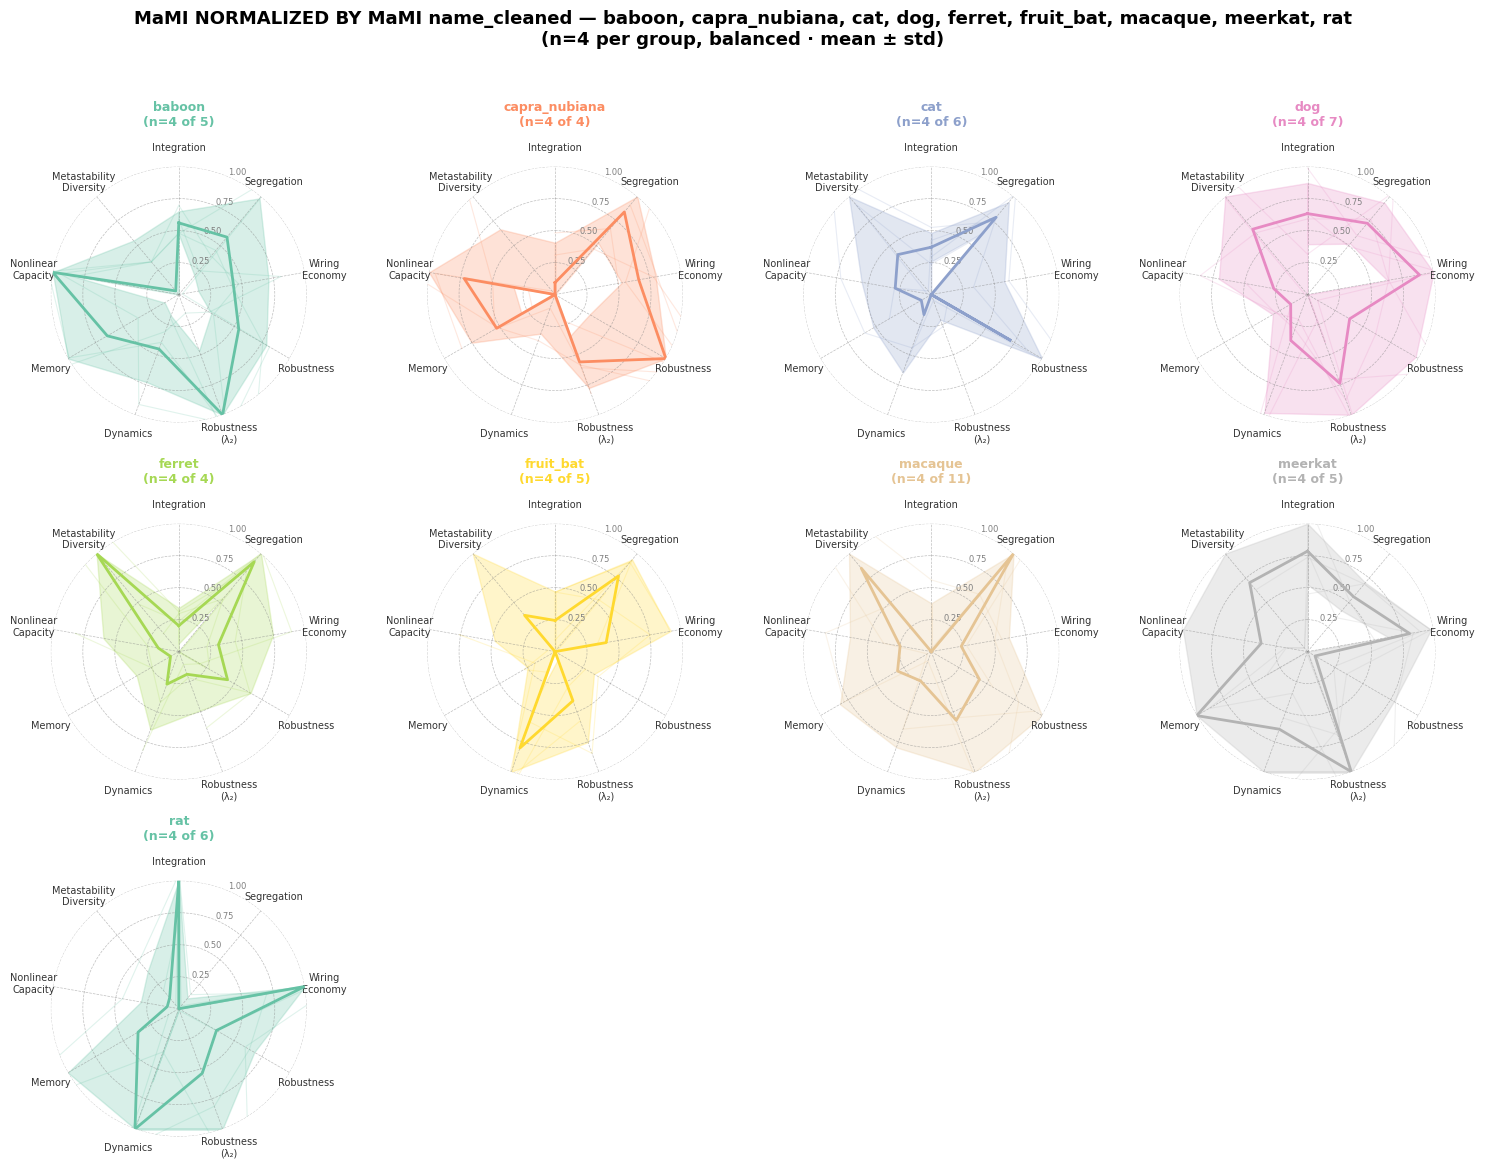

Saved → spider_mami_name_cleaned.png


In [112]:
# ── 0. Configuration ──────────────────────────────────────────────────────────
what_to_look_at   = "name_cleaned"
GROUPS_TO_INCLUDE = name_counts.keys()[:9] # [
                #     'Primates',
                #     'Rodentia',
                #     # 'Hyracoidea',
                #     'Carnivora',
                #     # 'Perissodactyla',
                #     # 'Chiroptera',
                #     'Cetartiodactyla',
                #     # 'Eulipotyphla',
                #     # 'Scandentia',
                #     # 'Xenarthra',
                #     # 'Lagomorpha',
                #     # 'Marsupialia'
                # ]

# None to include ALL groups # list(set(info_mami["order"])) #

# ── 1. Merge taxonomy with metric data ────────────────────────────────────────
mami_metrics = dict_with_all_datasets['suarez_MaMI_dataset'][SELECTED_COLS].reset_index(drop=True)
info_mami    = info_mami.reset_index(drop=True)

assert len(mami_metrics) == len(info_mami), \
    f"Row mismatch: metrics={len(mami_metrics)}, taxonomy={len(info_mami)}"

mami_full = pd.concat(
    [info_mami[['animal', 'common_name', what_to_look_at]], mami_metrics], axis=1
)

# ── 1b. Optional group filter ─────────────────────────────────────────────────
if GROUPS_TO_INCLUDE is not None:
    # Case-insensitive matching so "rodentia" == "Rodentia"
    available = mami_full[what_to_look_at].unique()
    matched   = [g for g in available
                 if g.lower() in [x.lower() for x in GROUPS_TO_INCLUDE]]
    not_found = [x for x in GROUPS_TO_INCLUDE
                 if x.lower() not in [g.lower() for g in available]]

    if not_found:
        print(f"⚠ The following groups were not found in '{what_to_look_at}' "
              f"and will be ignored: {not_found}")
    print(f"✓ Keeping {len(matched)} group(s): {sorted(matched)}")

    mami_full = mami_full[mami_full[what_to_look_at].isin(matched)].reset_index(drop=True)

# ── 2. Find minimum group size → sample that many per group ──────────────────
group_counts = mami_full.groupby(what_to_look_at).size()
print(f"\nAnimals per '{what_to_look_at}':")
print(group_counts.sort_values().to_string())
print(f"\n→ Minimum group size: {group_counts.min()} ({group_counts.idxmin()})")

N_PER_GROUP = group_counts.min()

sampled = (
    mami_full
    .groupby(what_to_look_at, group_keys=False)
    .apply(lambda g: g.sample(n=N_PER_GROUP, random_state=SEED))
    .reset_index(drop=True)
)

# ── 3. Compute per-group mean & std ───────────────────────────────────────────
group_stats = {}
for group, gdf in sampled.groupby(what_to_look_at):
    vals = gdf[SELECTED_COLS]
    group_stats[group] = (vals.mean(), vals.std(ddof=0).fillna(0))

# ── 4. Normalise across selected groups only ──────────────────────────────────
all_group_means = pd.DataFrame({k: v[0] for k, v in group_stats.items()}).T
g_min   = all_group_means.min()
g_max   = all_group_means.max()
g_range = (g_max - g_min).replace(0, 1)

# g_range = COL_RANGE
def normalise_mami(series):
    return (series - g_min) / g_range

# ── 5. Plot ───────────────────────────────────────────────────────────────────
n_groups  = len(group_stats)
PALETTE   = plt.cm.Set2.colors

ncols = min(4, n_groups)
nrows = int(np.ceil(n_groups / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 3.8, nrows * 3.8),
    subplot_kw=dict(polar=True)
)
axes_flat = np.array(axes).flatten()

for idx, (group, (mean_raw, std_raw)) in enumerate(sorted(group_stats.items())):
    # mean_n = normalise_mami(mean_raw).values
    mean_n = normalise_mami(mean_raw).values
    # std_n  = (std_raw / COL_RANGE).values
    std_n  = (std_raw / g_range).values
    color  = PALETTE[idx % len(PALETTE)]
    ax = axes_flat[idx]
    
    # ── Individual animal contours (low alpha) ────────────────────────────
    group_df = sampled[sampled[what_to_look_at] == group][SELECTED_COLS]
    n_cols   = len(SELECTED_COLS)
    angles   = np.linspace(0, 2 * np.pi, n_cols, endpoint=False).tolist()
    angles  += angles[:1]  # close the polygon

    for _, row in group_df.iterrows():
        ind_n  = normalise_mami(row).values.tolist()
        ind_n += ind_n[:1]  # close the polygon
        ax.plot(angles, ind_n, color=color, alpha=0.2, # 12, 
                linewidth=0.8)
        # ax.fill(angles, ind_n, color=color, alpha=0.03)
        

    make_spider(
        ax     = ax,
        values = mean_n,
        errors = std_n,
        labels = selected_properties.keys(), # SELECTED_COLS,
        color  = color,
        title  = f"{group}\n(n={N_PER_GROUP} of {group_counts[group]})",
    )

for ax in axes_flat[n_groups:]:
    ax.set_visible(False)

group_label = "all groups" if GROUPS_TO_INCLUDE is None else ", ".join(sorted(matched))
fig.suptitle(
    f'MaMI NORMALIZED BY MaMI {what_to_look_at} — {group_label}\n'
    f'(n={N_PER_GROUP} per group, balanced · mean ± std)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()

fname = f"spider_mami_{what_to_look_at}.png"
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {fname}")

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/02_circular_bars/legend_panel_empty.pdf


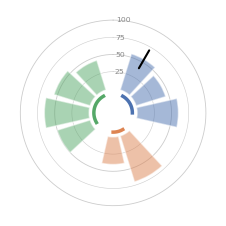

In [113]:
# ── Standalone legend panel ────────────────────────────────────────────────────
N_ANGLES = len(LABELS) + PAD * len(GROUP_SIZES)
ANGLES_LEG = np.linspace(0, 2 * np.pi, N_ANGLES, endpoint=False)
WIDTH_LEG  = (2 * np.pi) / N_ANGLES * 0.85

offset = 0
IDXS_LEG = []
for size in GROUP_SIZES:
    IDXS_LEG += list(range(offset + PAD, offset + PAD + size))
    offset += size + PAD

fig, ax_leg = plt.subplots(
    figsize=viz.cm_to_inch((6, 6)),
    subplot_kw=dict(projection="polar")
)

ax_leg.set_theta_offset(np.pi / 2)
ax_leg.set_theta_direction(-1)
ax_leg.set_ylim(-35, 115)
ax_leg.set_frame_on(False)
ax_leg.xaxis.grid(False)
ax_leg.yaxis.grid(False)
ax_leg.set_xticks([])
ax_leg.set_yticks([])

# Reference circles
theta_full = np.linspace(0, 2 * np.pi, 360)
for ref, lw in [(25, 0.4), (50, 0.6), (75, 0.4), (100, 0.6)]:
    ax_leg.plot(theta_full, [ref] * 360, color="#cccccc", lw=lw, zorder=0)
    ax_leg.text(np.radians(2), ref, f"{ref}",
                ha="left", va="center", fontsize=5.5, color="#888888", zorder=5)

# Placeholder bars
PLACEHOLDER = [55, 45, 60, 70, 40, 50, 65, 55, 45]
ax_leg.bar(
    ANGLES_LEG[IDXS_LEG], PLACEHOLDER,
    width=WIDTH_LEG, color=BAR_COLORS,
    edgecolor="white", linewidth=1,
    bottom=0, zorder=2, alpha=0.5
)

# One annotated error bar
eg_angle = ANGLES_LEG[IDXS_LEG[0]]
eg_val   = PLACEHOLDER[0]
eg_err   = 15
ax_leg.plot([eg_angle, eg_angle], [eg_val - eg_err, eg_val + eg_err],
            color="black", lw=1.5, zorder=4, solid_capstyle="round")
# ax_leg.annotate(
#     "±1 SD", xy=(eg_angle, eg_val + eg_err),
#     xytext=(eg_angle + np.radians(18), eg_val + eg_err + 12),
#     fontsize=6, color="#333333",
#     arrowprops=dict(arrowstyle="-", color="#888888", lw=0.8)
# )

# # Bar labels — horizontal, anchored by quadrant
# for angle, val, label in zip(ANGLES_LEG[IDXS_LEG], PLACEHOLDER, LABELS):
#     deg = np.degrees(angle) % 360
#     r_label = val + 12
#     if deg <= 90:
#         ha, va = "left", "bottom"
#     elif deg <= 180:
#         ha, va = "right", "bottom"
#     elif deg <= 270:
#         ha, va = "right", "top"
#     else:
#         ha, va = "left", "top"
#     ax_leg.text(angle, r_label, label,
#                 rotation=0, ha=ha, va=va,
#                 fontsize=6, color="#333333")

# Group underlines + names
offset = 0
for (gname, size, gcol) in GROUPS:
    start = offset + PAD
    end   = offset + PAD + size - 1
    x_line = np.linspace(ANGLES_LEG[start], ANGLES_LEG[end], 80)
    ax_leg.plot(x_line, [-7] * 80, color=gcol, lw=2.5)
    # ax_leg.text(np.mean(x_line), -20, gname,
    #             color=gcol, fontsize=6.5, fontweight="bold",
    #             ha="center", va="center")
    offset += size + PAD

# ax_leg.text(0, -35, "How to read",
#             ha="center", va="center",
#             fontsize=7.5, fontweight="bold", color="#444444")

plt.tight_layout()
fname = output_folder / "legend_panel_empty.pdf"
plt.savefig(fname, dpi=150, bbox_inches="tight")
print(fname)
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/02_circular_bars/legend_panel_empty_two_rings.pdf


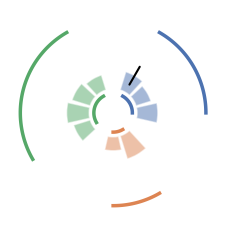

In [114]:
# ── Standalone legend panel ────────────────────────────────────────────────────
N_ANGLES = len(LABELS) + PAD * len(GROUP_SIZES)
ANGLES_LEG = np.linspace(0, 2 * np.pi, N_ANGLES, endpoint=False)
WIDTH_LEG  = (2 * np.pi) / N_ANGLES * 0.85

offset = 0
IDXS_LEG = []
for size in GROUP_SIZES:
    IDXS_LEG += list(range(offset + PAD, offset + PAD + size))
    offset += size + PAD

fig, ax_leg = plt.subplots(
    figsize=viz.cm_to_inch((6, 6)),
    subplot_kw=dict(projection="polar")
)

ax_leg.set_theta_offset(np.pi / 2)
ax_leg.set_theta_direction(-1)
ax_leg.set_ylim(-35, 115)
ax_leg.set_frame_on(False)
ax_leg.xaxis.grid(False)
ax_leg.yaxis.grid(False)
ax_leg.set_xticks([])
ax_leg.set_yticks([])

# Reference circles
# theta_full = np.linspace(0, 2 * np.pi, 360)
# for ref, lw in [(25, 0.4), (50, 0.6), (75, 0.4), (100, 0.6)]:
#     ax_leg.plot(theta_full, [ref] * 360, color="#cccccc", lw=lw, zorder=0)
#     ax_leg.text(np.radians(2), ref, f"{ref}",
#                 ha="left", va="center", fontsize=5.5, color="#888888", zorder=5)

# Placeholder bars
PLACEHOLDER = [55, 45, 60, 70, 40, 50, 65, 55, 45] 
PLACEHOLDER = [p / 2 for p in PLACEHOLDER]
ax_leg.bar(
    ANGLES_LEG[IDXS_LEG], PLACEHOLDER,
    width=WIDTH_LEG, color=BAR_COLORS,
    edgecolor="white", linewidth=1,
    bottom=0, zorder=2, alpha=0.5
)

# One annotated error bar
eg_angle = ANGLES_LEG[IDXS_LEG[0]]
eg_val   = PLACEHOLDER[0]
eg_err   = 15
ax_leg.plot([eg_angle, eg_angle], [eg_val - eg_err, eg_val + eg_err],
            color="black", lw=1.5, zorder=4, solid_capstyle="round")
# ax_leg.annotate(
#     "±1 SD", xy=(eg_angle, eg_val + eg_err),
#     xytext=(eg_angle + np.radians(18), eg_val + eg_err + 12),
#     fontsize=6, color="#333333",
#     arrowprops=dict(arrowstyle="-", color="#888888", lw=0.8)
# )

# # Bar labels — horizontal, anchored by quadrant
# for angle, val, label in zip(ANGLES_LEG[IDXS_LEG], PLACEHOLDER, LABELS):
#     deg = np.degrees(angle) % 360
#     r_label = val + 12
#     if deg <= 90:
#         ha, va = "left", "bottom"
#     elif deg <= 180:
#         ha, va = "right", "bottom"
#     elif deg <= 270:
#         ha, va = "right", "top"
#     else:
#         ha, va = "left", "top"
#     ax_leg.text(angle, r_label, label,
#                 rotation=0, ha=ha, va=va,
#                 fontsize=6, color="#333333")

# Group underlines + names
offset = 0
for (gname, size, gcol) in GROUPS:
    start = offset + PAD
    end   = offset + PAD + size - 1
    x_line = np.linspace(ANGLES_LEG[start], ANGLES_LEG[end], 80)
    ax_leg.plot(x_line, [-7] * 80, color=gcol, lw=2.5)
    # ax_leg.text(np.mean(x_line), -20, gname,
    #             color=gcol, fontsize=6.5, fontweight="bold",
    #             ha="center", va="center")
    offset += size + PAD



# Group underlines + names
offset = 0
for (gname, size, gcol) in GROUPS:
    start = offset + PAD
    end   = offset + PAD + size - 1
    x_line = np.linspace(ANGLES_LEG[start], ANGLES_LEG[end], 80)
    ax_leg.plot(x_line, [100] * 80, color=gcol, lw=2.5)
    # ax_leg.text(np.mean(x_line), -20, gname,
    #             color=gcol, fontsize=6.5, fontweight="bold",
    #             ha="center", va="center")
    offset += size + PAD
    
    
# ax_leg.text(0, -35, "How to read",
#             ha="center", va="center",
#             fontsize=7.5, fontweight="bold", color="#444444")

plt.tight_layout()
fname = output_folder / "legend_panel_empty_two_rings.pdf"
plt.savefig(fname, dpi=150, bbox_inches="tight")
print(fname)
plt.show()